In [ ]:
import os
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict, Annotated, List
from langchain_groq import ChatGroq
from sqlalchemy import text
from sqlalchemy import inspect
from langchain_classic import PromptTemplate

In [ ]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
import pandas as pd

df = pd.read_csv("data/house_price.csv")

unit_multiplier = {"Cr": 100, "L": 1}
df["price_lakh"] = (
    (df["price"] * df["price_unit"].map(unit_multiplier)).round().astype("int64")
)

df = df.drop(columns=["Unnamed: 0", "price", "price_unit"])

print(df.head())

   bhk       type  area   region              status  price_lakh
0    3  Apartment  1076  Andheri  Under Construction         319
1    3  Apartment  1076  Andheri  Under Construction         319
2    3  Apartment  1076  Andheri  Under Construction         319
3    2  Apartment   718  Andheri  Under Construction         212
4    3  Apartment  1076  Andheri  Under Construction         319


In [117]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///house_prices.db")

In [118]:
df.to_sql("house_prices", engine, if_exists="replace", index=False)

5042

In [122]:
inspector = inspect(engine)

tables = inspector.get_table_names()

schema = {}

for table in tables:
    columns = inspector.get_columns(table)
    schema[table] = [col["name"] for col in columns]

In [123]:
class SQLState(TypedDict):
    question: str
    first_llm: str
    second_llm: str
    answer: list

In [124]:
def text_to_sql(state: SQLState):
    template = PromptTemplate.from_template(
        """You are a SQL expert. Your task is to convert natural language questions into valid SQL queries.

Database Schema:
{schema}

Instructions:
1. Analyze the question carefully
2. Generate ONLY a valid SQL query based on the schema
3. Do NOT include any explanations, notes, or extra text
4. Ensure proper SQL syntax
5. Return ONLY the SQL query, nothing else

Question:
{question}

SQL Query:"""
    )

    chain = template | llm

    op = chain.invoke({"schema": schema, "question": state["question"]})

    return {"first_llm": op.content}

In [ ]:
def validator_sql_query(state: SQLState):
    template = PromptTemplate.from_template(
        """You are a SQL expert. Your task is to validate and correct SQL queries.

Database Schema:
{schema}

Original Question:
{question}

Generated SQL Query:
{query}

Instructions:
1. Validate the SQL query against the schema and the original question
2. If the query is VALID: return it as-is
3. If the query is INVALID: generate the correct query
4. Return ONLY the SQL query - no explanations, comments, or extra text
5. Ensure the query properly answers the original question

Corrected SQL Query:"""
    )
    chain = template | llm

    res = chain.invoke(
        {"schema": schema, "question": state["question"], "query": state["first_llm"]}
    )

    return {"second_llm": res.content}

In [126]:
def answer_generator(state: SQLState):
    with engine.connect() as conn:
        result = conn.execute(text(state["second_llm"]))
        answer = result.fetchall()

    return {"answer": answer}

In [127]:
graph = StateGraph(SQLState)
graph.add_node("text_to_sql", text_to_sql)
graph.add_node("validator_sql_query", validator_sql_query)
graph.add_node("answer_generator", answer_generator)
graph.add_edge(START, "text_to_sql")
graph.add_edge("text_to_sql", "validator_sql_query")
graph.add_edge("validator_sql_query", "answer_generator")
graph.add_edge("answer_generator", END)

app = graph.compile()

In [130]:
result = app.invoke(
    {"question": "What is max price of house from db?", "schema": schema}
)

In [131]:
print(result)

{'question': 'What is max price of house from db?', 'first_llm': 'SELECT MAX price_lakh FROM house_prices', 'second_llm': 'SELECT MAX(price_lakh) FROM house_prices', 'answer': [(5000,)]}


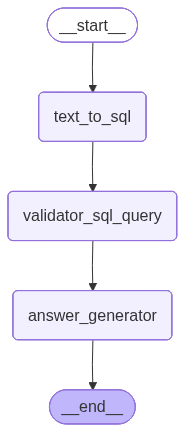

In [132]:
graph.compile()